# Deep Learning with PyTorch Step-by-Step: A Beginner's Guide

# Chapter 2

In [80]:
try:
    import google.colab
    import requests
    url = 'https://raw.githubusercontent.com/dvgodoy/PyTorchStepByStep/master/config.py'
    r = requests.get(url, allow_redirects=True)
    open('config.py', 'wb').write(r.content)    
except ModuleNotFoundError:
    pass

from config import *
config_chapter2()
# This is needed to render the plots in this chapter
from plots.chapter2 import *

In [81]:
import numpy as np
from sklearn.linear_model import LinearRegression

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data.dataset import random_split
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

# 回顾训练循环

### 模型训练 V0

In [82]:
# 数据生成
%run -i data_generation/simple_linear_regression.py

# 数据准备和模型配置

%run -i data_preparation/v0.py
%run -i model_configuration/v0.py

In [83]:
# %load model_training/v0.py

# 定义周期数
n_epochs = 1000

for epoch in range(n_epochs):
    # Sets model to TRAIN mode
    model.train()

    # Step 1 -前向传播
    # 直接调用模型类而不是调用函数
    yhat = model(x_train_tensor)
    
    # Step 2 - 计算损失
    loss = loss_fn(yhat, y_train_tensor)

    # Step 3 - 计算权重和偏置的梯度
    loss.backward()
    
    # Step 4 - 更新参数
    optimizer.step()
    optimizer.zero_grad()

In [84]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9690]], device='cuda:0')), ('0.bias', tensor([1.0235], device='cuda:0'))])


## 高阶函数

In [85]:
def square(x):
    return x ** 2

def cube(x):
    return x ** 3

def fourth_power(x):
    return x ** 4

# and so on and so forth...

In [86]:
def generic_exponentiation(x, exponent):
    return x ** exponent

In [87]:
def skeleton_exponentiation(x):
    return x ** exponent

In [88]:
# NameError: name 'exponent' is not defined
# skeleton_exponentiation(2)

In [89]:
def exponentiation_builder(exponent):
    def skeleton_exponentiation(x):
        return x ** exponent

    return skeleton_exponentiation

In [90]:
returned_function = exponentiation_builder(2)

returned_function

<function __main__.exponentiation_builder.<locals>.skeleton_exponentiation(x)>

In [91]:
returned_function(5)

25

In [92]:
square = exponentiation_builder(2)
cube = exponentiation_builder(3)
fourth_power = exponentiation_builder(4)

# and so on and so forth...

### 辅助函数1: 抽象训练循环内的内容

In [93]:
# 需要: 模型类,损失函数,优化器
def make_train_step_fn(model, loss_fn, optimizer):
    # Builds function that performs a step in the train loop
    def perform_train_step_fn(x, y):
        # 注意！一定要设置模型的模式
        model.train()
        
        # Step 1 - 前向传播
        yhat = model(x)
        # Step 2 - 计算损失
        loss = loss_fn(yhat, y)
        # Step 3 - 计算权重和偏置的梯度
        loss.backward()
        # Step 4 - 更新参数
        optimizer.step()
        optimizer.zero_grad()
        
        # 返回损失
        return loss.item()
    
    # Returns the function that will be called inside the train loop
    return perform_train_step_fn

### 模型配置 V1

In [94]:
# 数据准备

%run -i data_preparation/v0.py

In [95]:
%%writefile model_configuration/v1.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 设置学习率
lr = 0.1

torch.manual_seed(42)
# 创建模型类并上传GPU
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# 定义更新器
optimizer = optim.SGD(model.parameters(), lr=lr)

# 定义损失函数
loss_fn = nn.MSELoss(reduction='mean')

# 创建每次训练循环的函数
train_step_fn = make_train_step_fn(model, loss_fn, optimizer)

Overwriting model_configuration/v1.py


In [96]:
# 模型配置

%run -i model_configuration/v1.py

In [97]:
train_step_fn

<function __main__.make_train_step_fn.<locals>.perform_train_step_fn(x, y)>

### 模型训练 V1

In [98]:
%%writefile model_training/v1.py

# 定义周期数
n_epochs = 1000

# 记录每次循环的损失
losses = []

# For each epoch...
for epoch in range(n_epochs):
    # 随机梯度下降：全部训练数据，训练N遍
    loss = train_step_fn(x_train_tensor, y_train_tensor)
    losses.append(loss)

Overwriting model_training/v1.py


In [99]:
# 模型训练

%run -i model_training/v1.py

In [100]:
# 检查模型参数
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9690]], device='cuda:0')), ('0.bias', tensor([1.0235], device='cuda:0'))])


# Dataset

### 自定义Dataset

In [101]:
class CustomDataset(Dataset):
    def __init__(self, x_tensor, y_tensor):
        self.x = x_tensor
        self.y = y_tensor
        
    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return len(self.x)

# 这里还是CPU上的张量
x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train).float()

# 生成元组
train_data = CustomDataset(x_train_tensor, y_train_tensor)
print(train_data[0])

(tensor([0.7713]), tensor([2.4745]))


## TensorDataset

简单的向量dataset就直接用tensordataset即可

In [102]:
train_data = TensorDataset(x_train_tensor, y_train_tensor)
print(train_data[0])

(tensor([0.7713]), tensor([2.4745]))


## DataLoader

loader类似迭代器，可以用于遍历dataset

In [103]:
train_loader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)

In [104]:
next(iter(train_loader))

[tensor([[0.2809],
         [0.3253],
         [0.1560],
         [0.5924],
         [0.0651],
         [0.8872],
         [0.4938],
         [0.0055],
         [0.1409],
         [0.0885],
         [0.1849],
         [0.7290],
         [0.8662],
         [0.3117],
         [0.6842],
         [0.1987]]),
 tensor([[1.5846],
         [1.8057],
         [1.2901],
         [2.1687],
         [1.1559],
         [2.8708],
         [1.9060],
         [1.0632],
         [1.1211],
         [1.0708],
         [1.5888],
         [2.4927],
         [2.6805],
         [1.7637],
         [2.3492],
         [1.2654]])]

### 数据准备 V1

In [105]:
%%writefile data_preparation/v1.py

# Our data was in Numpy arrays, but we need to transform them into PyTorch's Tensors
x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train).float()

# 用dataset和dataloader准备数据代替手动散装传递
# 而且能实现minibatch的训练

# Builds Dataset
train_data = TensorDataset(x_train_tensor, y_train_tensor)

# Builds DataLoader
train_loader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)

Overwriting data_preparation/v1.py


In [106]:
%run -i data_preparation/v1.py

### 模型训练 V2

In [107]:
# 模型参数准备(暂时没有修改)
%run -i model_configuration/v1.py

In [108]:
%%writefile model_training/v2.py

# 定义epoch循环次数(训练周期)
n_epochs = 1000

losses = []

# For each epoch...
for epoch in range(n_epochs):
    # inner loop
    mini_batch_losses = []
    for x_batch, y_batch in train_loader:
        # 每次只上传一个minibatch到GPU
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # 执行一次训练循环,记录损失
        mini_batch_loss = train_step_fn(x_batch, y_batch)
        mini_batch_losses.append(mini_batch_loss)

    # 对每个minibatch取平均损失
    loss = np.mean(mini_batch_losses)
    
    losses.append(loss)

Overwriting model_training/v2.py


In [109]:
# 训练次数多了，时长自然稍微长一点
%run -i model_training/v2.py

In [110]:
# 模型参数
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9696]], device='cuda:0')), ('0.bias', tensor([1.0243], device='cuda:0'))])


## Mini-Batch 内循环

### Helper Function #2: 抽象每个minibatch的训练循环

In [111]:
def mini_batch(device, data_loader, step_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        mini_batch_loss = step_fn(x_batch, y_batch)
        mini_batch_losses.append(mini_batch_loss)

    loss = np.mean(mini_batch_losses)
    return loss

### Model Training V3

In [112]:
%run -i data_preparation/v1.py
%run -i model_configuration/v1.py

In [113]:
%%writefile model_training/v3.py

# Defines number of epochs
# 因为有内循环所以统一学习次数
n_epochs = 200

losses = []

for epoch in range(n_epochs):
    # inner loop
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)

Overwriting model_training/v3.py


In [114]:
%run -i model_training/v3.py

In [115]:
# Checks model's parameters
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9684]], device='cuda:0')), ('0.bias', tensor([1.0219], device='cuda:0'))])


## Random Split: 随机划分训练和验证集

### 数据准备 V2

In [116]:
%%writefile data_preparation/v2.py

torch.manual_seed(13)

# Builds tensors from numpy arrays BEFORE split
x_tensor = torch.from_numpy(x).float()
y_tensor = torch.from_numpy(y).float()

# Builds dataset containing ALL data points
dataset = TensorDataset(x_tensor, y_tensor)

# Performs the split
# 划分是靠总长和比例生成最终长度来划分的
ratio = .8
n_total = len(dataset)
n_train = int(n_total * ratio)
n_val = n_total - n_train

# 各自设定 dataset和loader: random_split函数
train_data, val_data = random_split(dataset, [n_train, n_val])


# Builds a loader of each set
train_loader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=16)

Overwriting data_preparation/v2.py


In [117]:
%run -i data_preparation/v2.py

# Evaluation：评估模型

### Helper Function #3: 抽象评估损失计算

In [118]:
def make_val_step_fn(model, loss_fn):
    # Builds function that performs a step in the validation loop
    def perform_val_step_fn(x, y):
        # 设定评估模式,规避一些算法的特殊行为(如dropout)
        model.eval()
        
        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model(x)
        # Step 2 - Computes the loss
        loss = loss_fn(yhat, y)
        # There is no need to compute Steps 3 and 4, since we don't update parameters during evaluation
        return loss.item()
    
    return perform_val_step_fn

### 模型配置 V2: 添加评估部分的损失计算

In [119]:
%%writefile model_configuration/v2.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sets learning rate - this is "eta" ~ the "n" like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# Creates the train_step function for our model, loss function and optimizer
train_step_fn = make_train_step_fn(model, loss_fn, optimizer)

# Creates the val_step function for our model and loss function
val_step_fn = make_val_step_fn(model, loss_fn)

Overwriting model_configuration/v2.py


In [120]:
%run -i model_configuration/v2.py

### Model Training V4

In [121]:
%%writefile model_training/v4.py

# Defines number of epochs
n_epochs = 200

losses = []
val_losses = []

for epoch in range(n_epochs):
    # inner loop
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)
    
    # VALIDATION: 验证
    # 注意这里上下文为的是取消多余的梯度计算
    with torch.no_grad():
        val_loss = mini_batch(device, val_loader, val_step_fn)
        val_losses.append(val_loss)    

Overwriting model_training/v4.py


In [122]:
%run -i model_training/v4.py

In [123]:
# Checks model's parameters
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9438]], device='cuda:0')), ('0.bias', tensor([1.0287], device='cuda:0'))])


## Plotting Losses: 可视化

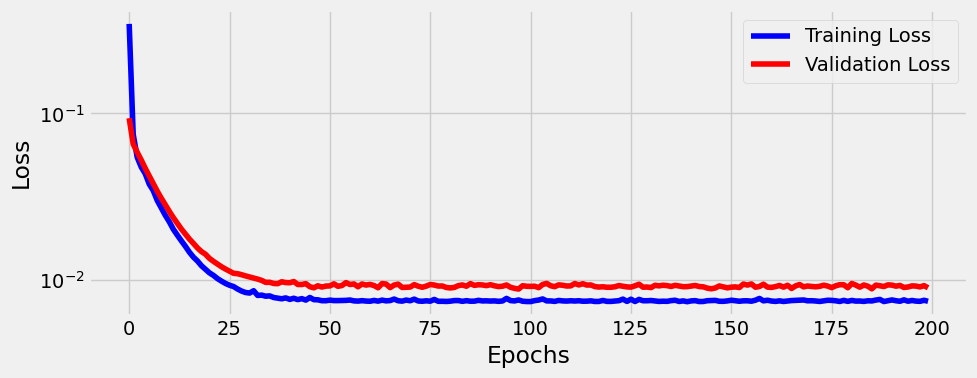

In [124]:
fig = plot_losses(losses, val_losses)

# TensorBoard: 另一种可视化方式

In [46]:
# tensorboard_cleanup()

In [128]:
if IS_BINDER:
    display(TB_LINK)
else:
    %load_ext tensorboard
    %tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 31832), started 0:05:00 ago. (Use '!kill 31832' to kill it.)

## SummaryWriter

In [126]:
# 创建一个SummaryWriter对象,用于写入日志,供TensorBoard可视化
# 目录是固定的runs
writer = SummaryWriter('runs/test')

## add_graph

In [131]:
# 需要将一些输入与模型一起发送
# writer.add_graph(model)

In [127]:
# 获取特征(dummy_x)和标签(dummy_y)的元组
sample_x, sample_y = next(iter(train_loader))

# 由于模型已发送到设备，因此需要对数据执行相同的操作
# 因此在这里，模型和数据也需要在同一台设备上
writer.add_graph(model, sample_x.to(device))

## add_scalars

In [129]:
# 可以使用add_scalars方法一次性发送多个标量值
# 参数:组tag,键值对字典,全局步长
writer.add_scalars('loss', {'training': loss, 'validation': val_loss}, epoch)

### 模型配置 V3

In [130]:
# 数据准备不变
%run -i data_preparation/v2.py

<Figure size 640x480 with 0 Axes>

In [134]:
%%writefile model_configuration/v3.py
# 添加可视化writer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sets learning rate - this is "eta" ~ the "n" like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# Creates the train_step function for our model, loss function and optimizer
train_step_fn = make_train_step_fn(model, loss_fn, optimizer)

# Creates the val_step function for our model and loss function
val_step_fn = make_val_step_fn(model, loss_fn)

# Creates a Summary Writer to interface with TensorBoard
writer = SummaryWriter('runs/simple_linear_regression')

# 取单个小批量，以便可以使用add_graph
x_sample, y_sample = next(iter(train_loader))
writer.add_graph(model, x_sample.to(device))

Overwriting model_configuration/v3.py


In [135]:
%run -i model_configuration/v3.py

### 模型训练 V5

In [136]:
%%writefile model_training/v5.py

# Defines number of epochs
n_epochs = 200

losses = []
val_losses = []

for epoch in range(n_epochs):
    # inner loop
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)
    
    # VALIDATION
    # no gradients in validation!
    with torch.no_grad():
        val_loss = mini_batch(device, val_loader, val_step_fn)
        val_losses.append(val_loss)
    
    # Records both losses for each epoch under the main tag "loss"
    # 在主标签“损失”下记录每个周期的损失
    writer.add_scalars(main_tag='loss',
                       tag_scalar_dict={'training': loss, 'validation': val_loss},
                       global_step=epoch)

# Closes the writer
writer.close()

Overwriting model_training/v5.py


In [137]:
%run -i model_training/v5.py

In [138]:
# Checks model's parameters
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9432]], device='cuda:0')), ('0.bias', tensor([1.0263], device='cuda:0'))])


# Saving and Loading Models

## Saving

### Cell 2.4

In [59]:
checkpoint = {'epoch': n_epochs,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'loss': losses,
              'val_loss': val_losses}

torch.save(checkpoint, 'model_checkpoint.pth')

## Resuming Training

### Cell 2.5

In [60]:
%run -i data_preparation/v2.py
%run -i model_configuration/v3.py

In [61]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[0.7645]], device='cuda:0')), ('0.bias', tensor([0.8300], device='cuda:0'))])


### Cell 2.6

In [62]:
checkpoint = torch.load('model_checkpoint.pth', weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

saved_epoch = checkpoint['epoch']
saved_losses = checkpoint['loss']
saved_val_losses = checkpoint['val_loss']

model.train() # always use TRAIN for resuming training

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)

In [63]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9448]], device='cuda:0')), ('0.bias', tensor([1.0295], device='cuda:0'))])


### Cell 2.7

In [64]:
%run -i model_training/v5.py

In [65]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9448]], device='cuda:0')), ('0.bias', tensor([1.0295], device='cuda:0'))])


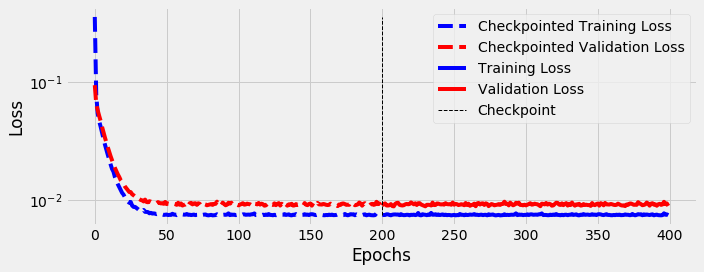

In [66]:
fig = plot_resumed_losses(saved_epoch, saved_losses, saved_val_losses, n_epochs, losses, val_losses)

## Deploying / Making Predictions

### Cell 2.8

In [67]:
%run -i model_configuration/v3.py

<Figure size 432x288 with 0 Axes>

### Cell 2.9

In [68]:
checkpoint = torch.load('model_checkpoint.pth', weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9448]], device='cuda:0')), ('0.bias', tensor([1.0295], device='cuda:0'))])


### Cell 2.10

In [69]:
new_inputs = torch.tensor([[.20], [.34], [.57]])

model.eval() # always use EVAL for fully trained models!
model(new_inputs.to(device))

tensor([[1.4185],
        [1.6908],
        [2.1381]], device='cuda:0', grad_fn=<AddmmBackward>)

# Putting It All Together

In [70]:
# %load data_preparation/v2.py

torch.manual_seed(13)

# Builds tensors from numpy arrays BEFORE split
x_tensor = torch.from_numpy(x).float()
y_tensor = torch.from_numpy(y).float()

# Builds dataset containing ALL data points
dataset = TensorDataset(x_tensor, y_tensor)

# Performs the split
ratio = .8
n_total = len(dataset)
n_train = int(n_total * ratio)
n_val = n_total - n_train

train_data, val_data = random_split(dataset, [n_train, n_val])

# Builds a loader of each set
train_loader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=16)

In [71]:
# %load model_configuration/v3.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sets learning rate - this is "eta" ~ the "n" like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# Creates the train_step function for our model, loss function and optimizer
train_step_fn = make_train_step_fn(model, loss_fn, optimizer)

# Creates the val_step function for our model and loss function
val_step_fn = make_val_step_fn(model, loss_fn)

# Creates a Summary Writer to interface with TensorBoard
writer = SummaryWriter('runs/simple_linear_regression')

# Fetches a single mini-batch so we can use add_graph
x_sample, y_sample = next(iter(train_loader))
writer.add_graph(model, x_sample.to(device))

In [72]:
# %load model_training/v5.py

# Defines number of epochs
n_epochs = 200

losses = []
val_losses = []

for epoch in range(n_epochs):
    # inner loop
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)
    
    # VALIDATION
    # no gradients in validation!
    with torch.no_grad():
        val_loss = mini_batch(device, val_loader, val_step_fn)
        val_losses.append(val_loss)
    
    # Records both losses for each epoch under the main tag "loss"
    writer.add_scalars(main_tag='loss',
                       tag_scalar_dict={'training': loss, 'validation': val_loss},
                       global_step=epoch)

# Closes the writer
writer.close()

In [73]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9448]], device='cuda:0')), ('0.bias', tensor([1.0295], device='cuda:0'))])


### Weird plots in TensorBoard?

Run this if you want to clean up a previous run and start fresh with TensorBoard :-)

In [73]:
import shutil

shutil.rmtree('./runs/simple_linear_regression/', ignore_errors=True)